# **Music Representations**

### **第一章 音乐表示**

**Introduction：**

1. Time Domain Waveform（时域波形）
2. Frequency Domain（频域）
3. Spectrogram（声谱图）
4. Mel Spectrogram（Mel 频谱图）
5. MFCC
6. MIDI Representation (Symbolic)（MIDI 符号表示）
7. MIDI Piano Roll
---
8. Encodec Tokens (下一章节)

In [ ]:
!pip install -q librosa soundfile matplotlib numpy scipy torch torchaudio pretty_midi

DEPRECATION: pytorch-lightning 1.7.7 has a non-standard dependency specifier torch>=1.9.*. pip 24.0 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of pytorch-lightning or contact the author to suggest that they release a version with a conforming dependency specifiers. Discussion can be found at https://github.com/pypa/pip/issues/12063

[notice] A new release of pip is available: 23.3.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


### **1. Load Audio (Waveform)**

**1、读取音频 + 播放**：音频来源 https://freesound.org/people/LilMati/sounds/657944/  公开.wav文件：10s 钢琴音色

In [ ]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
import IPython.display as ipd

audio_path = "657944__lilmati__skeleton-playing-piano-02.wav"

y, sr = librosa.load(audio_path, sr=24000)

print("Sample Rate:", sr)
print("Waveform shape:", y.shape)

ipd.display(ipd.Audio(y, rate=sr))

Sample Rate: 24000
Waveform shape: (240011,)


### **2. Time Domain Waveform View**

**2、时域波形**：信号的振幅 随 时间 变化的图像。

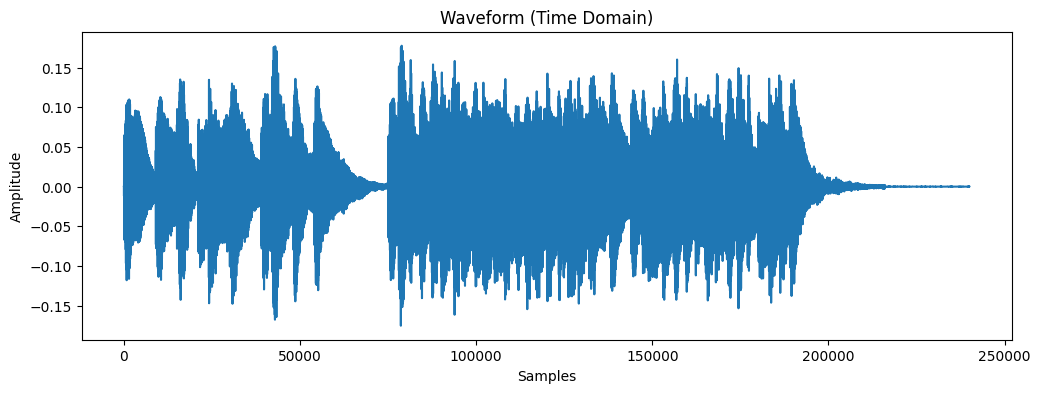

In [ ]:
plt.figure(figsize=(12,4))
plt.plot(y)
plt.title("Waveform (Time Domain)")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()

### **3. Frequency Domain (FFT)**

**3、频域**

Frequency Domain（频域）就是看“信号由哪些频率组成”

- 在时域里我们看的是：信号随时间怎么变化
- 在频域里我们看的是：信号里包含哪些频率？每个频率有多强？

**FFT** = Fast Fourier Transform（**快速傅里叶变换**）

它是计算傅里叶变换的一种高效算法。所以，FFT 是用来**把时域信号转换到频域**的算法

傅里叶变换的核心思想：

- 任何复杂信号，都可以分解成很多不同频率的正弦波叠加。
- 也就是：复杂波形（时域） = 一堆不同频率的波加在一起（频域）

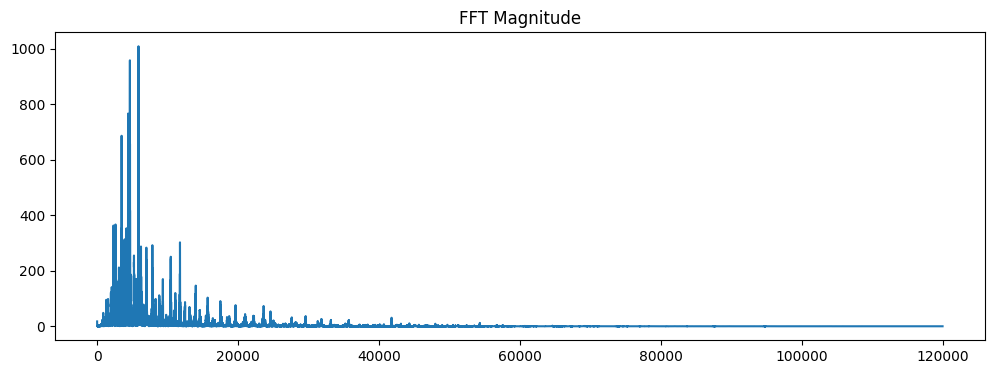

In [ ]:
fft = np.fft.fft(y)
magnitude = np.abs(fft)

plt.figure(figsize=(12,4))
plt.plot(magnitude[:len(magnitude)//2])
plt.title("FFT Magnitude")
plt.show()

### **4. Spectrogram (STFT)**

4、Spectrogram（**声谱图**）：“频率随时间变化”的图

STFT（短时傅里叶变换）：计算声谱图的方法（不再“把整段音乐 FFT” 而是“分时间段FFT”）

它解决了一个问题：

- 普通 FFT 只能看到“整体有哪些频率”
- 但现实信号（比如说话、音乐）频率是随时间变化的

所以 **STFT（Short-Time Fourier Transform）**：

- 一小段一小段地做 FFT（每一小段时间里有哪些频率？它们的强度？）
- 然后把结果拼起来


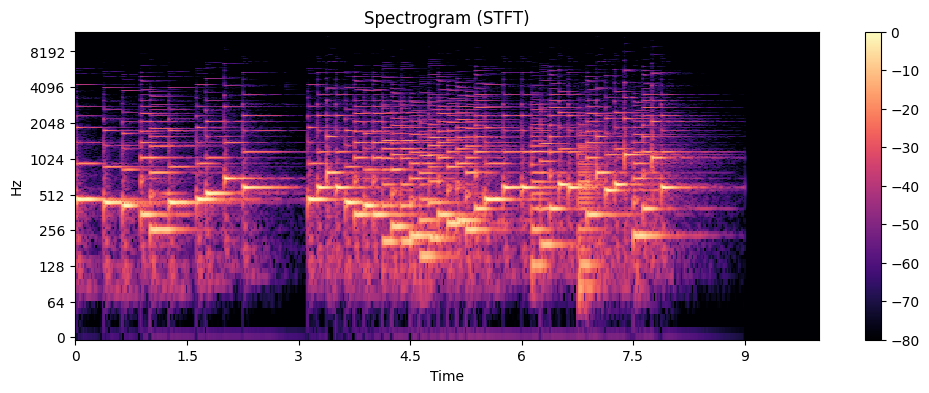

In [ ]:
D = librosa.stft(y)
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

plt.figure(figsize=(12,4))
librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='log')
plt.colorbar()
plt.title("Spectrogram (STFT)")
plt.show()

### **5. Mel Spectrogram**

5、Mel Spectrogram（**Mel 频谱图**）：用“人耳听觉刻度”表示的声谱图

它是 Spectrogram（STFT 结果） 的升级版，更符合人耳对声音的感知方式。

因为人耳听觉：

- 低频：分辨率高（人耳敏感）
- 高频：分辨率低（人耳不敏感）

所以 **Mel 刻度**（是一种“听觉刻度”）与 **普通 Spectrogram** 的不同就是：

- 低频部分更“拉伸”
- 高频被压缩
- 这样就会更符合人耳听感

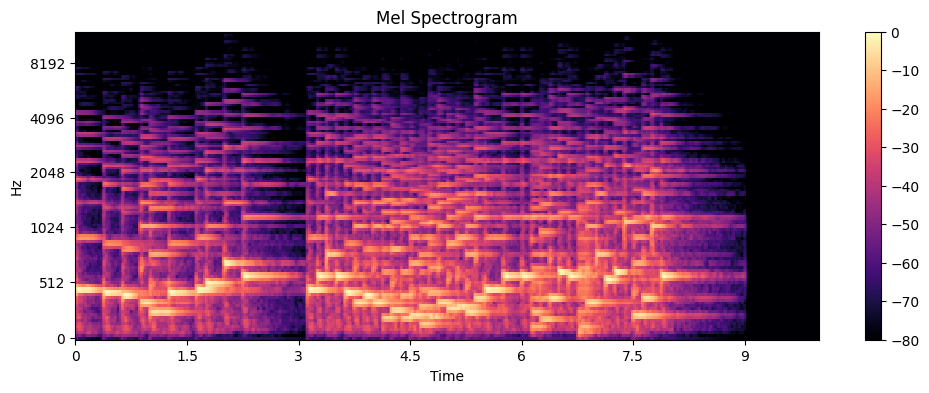

In [ ]:
mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
mel_db = librosa.power_to_db(mel, ref=np.max)

plt.figure(figsize=(12,4))
librosa.display.specshow(mel_db, sr=sr, x_axis='time', y_axis='mel')
plt.colorbar()
plt.title("Mel Spectrogram")
plt.show()

**Mel Spectrogram** 很重要：它几乎是所有语音 AI 的标准输入。

用在：

- 语音识别（ASR）
- 语音合成（TTS）
- 音乐分类
- 说话人识别
- 语音大模型

因为：

**神经网络更容易从 Mel 表示中学到有意义的特征**

---

### **6. MFCC**

6、MFCC（**Mel 频率倒谱系数**）：从声音中提取“人耳感知特征”的一组数字特征。

MFCC（Mel Frequency Cepstral Coefficients）是语音识别里最经典、最常用的特征之一。

- Mel → Mel 刻度：用人耳听觉刻度
- Frequency → 频率：来自频域分析
- Cepstral → 倒谱：对频谱再做一次变换
- Coefficients → 系数：最终输出的是一组数字

MFCC 提取的是：**声音的整体频谱形**，而不是具体频率峰值。

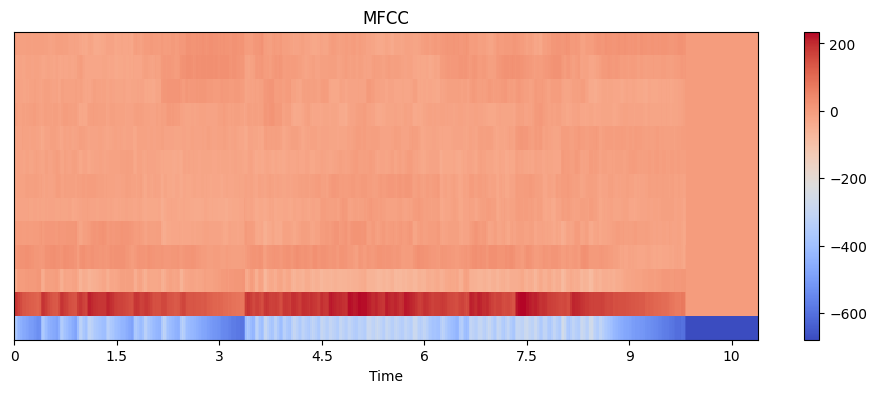

MFCC shape: (13, 469)


In [ ]:
mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)

plt.figure(figsize=(12,4))
librosa.display.specshow(mfcc, x_axis='time')
plt.colorbar()
plt.title("MFCC")
plt.show()

print("MFCC shape:", mfcc.shape)

### **7. MIDI Representation (Symbolic)**

**7、MIDI 符号表示** (Musical Instrument Digital Interface)：一种音乐数据协议，用来描述“演奏动作”。

“Symbolic” 的意思是：用符号规则表示音乐结构，而不是连续信号

在 AI 里，Symbolic 音乐通常是：

- 音高（pitch）
- 起始时间（onset）
- 时值（duration）
- 力度（velocity）

In [ ]:
import pretty_midi

midi = pretty_midi.PrettyMIDI("657944__lilmati__skeleton-playing-piano-02.mid")

for note in midi.instruments[0].notes[:10]:
    print("Pitch:", note.pitch,
          "Start:", note.start,
          "End:", note.end)

Pitch: 70 Start: 0.011363636363636364 End: 0.3704545454545454
Pitch: 69 Start: 0.3840909090909091 End: 0.6272727272727272
Pitch: 68 Start: 0.6272727272727272 End: 0.8818181818181817
Pitch: 65 Start: 0.8704545454545454 End: 1.2545454545454544
Pitch: 65 Start: 1.2545454545454544 End: 1.5681818181818181
Pitch: 60 Start: 0.9977272727272727 End: 1.5909090909090908
Pitch: 69 Start: 1.2545454545454544 End: 1.625
Pitch: 70 Start: 1.625 End: 1.95
Pitch: 72 Start: 1.7636363636363634 End: 2.2068181818181816
Pitch: 70 Start: 2.068181818181818 End: 2.3


从输出中可以看到：

比如第二行：

- 在 0.384 秒时按下一个音高为 60 的音（对应的音 应该是 A4，中央A）
- 在 0.627 秒时松开
- 持续时间 ≈ 0.243 秒

---

### **8. MIDI Piano Roll**

8、钢琴卷轴（转换图示）

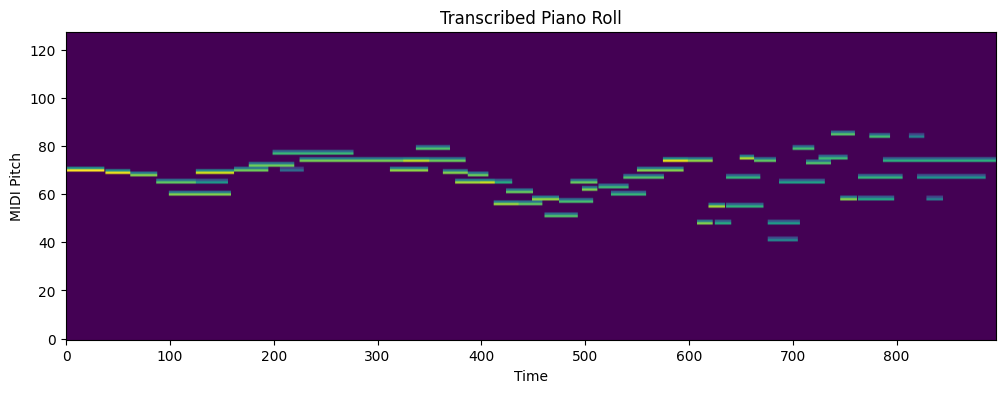

In [ ]:
piano_roll = midi.get_piano_roll(fs=100)

plt.figure(figsize=(12,4))
plt.imshow(piano_roll, aspect='auto', origin='lower')
plt.title("Transcribed Piano Roll")
plt.xlabel("Time")
plt.ylabel("MIDI Pitch")
plt.show()

### **9. MIDI Playback**

9、MIDI 回放

In [ ]:
audio = midi.synthesize()
ipd.display(ipd.Audio(audio, rate=44100))

这是按照 MIDI 播放的音频。可以听到它的音调与最初的音频相同。